In [1]:
import pandas as pd
pd.set_option('display.max_columns', 10)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, HTML
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
from sklearn.pipeline import Pipeline
import joblib

In [2]:
df =pd.read_parquet('books.parquet')
data  = df.copy()
df.shape

(26239, 25)

In [3]:
#info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26239 entries, 0 to 26238
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            26239 non-null  str    
 1   title             26239 non-null  str    
 2   series            11855 non-null  str    
 3   author            26239 non-null  str    
 4   rating            26239 non-null  float64
 5   description       25579 non-null  str    
 6   language          24343 non-null  str    
 7   isbn              26239 non-null  str    
 8   genres            26239 non-null  str    
 9   characters        26239 non-null  str    
 10  bookFormat        25524 non-null  str    
 11  edition           2494 non-null   str    
 12  pages             25050 non-null  str    
 13  publisher         24386 non-null  str    
 14  publishDate       25792 non-null  str    
 15  firstPublishDate  15576 non-null  str    
 16  awards            26239 non-null  str    
 17  numR

In [4]:
# null values can be seen, let's check
df.isna().sum()

bookId                  0
title                   0
series              14384
author                  0
rating                  0
description           660
language             1896
isbn                    0
genres                  0
characters              0
bookFormat            715
edition             23745
pages                1189
publisher            1853
publishDate           447
firstPublishDate    10663
awards                  0
numRatings              0
ratingsByStars          0
likedPercent          298
setting                 0
coverImg              319
bbeScore                0
bbeVotes                0
price                7158
dtype: int64

In [5]:
#head
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
0,6060069-tracy,Tracy,NaN,Gary McKay,4.17,...,[],https://i.gr-assets.com/images/S/compressed.ph...,83,1,2.86
1,16705.Summerland,Summerland,NaN,Michael Chabon,3.56,...,[],https://i.gr-assets.com/images/S/compressed.ph...,100,1,NaN


In [6]:
#duplicates by title and author
df.duplicated(subset= [ 'title' , 'author']).sum()

np.int64(26)

In [7]:
#check those duplicates
df[df.duplicated(subset= [ 'title' , 'author'])]

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
2590,1258333.Cantarella_Volume_1,"Cantarella, Volume 1",Cantarella #1,You Higuri,3.81,...,['Italy'],https://i.gr-assets.com/images/S/compressed.ph...,87,1,4.67
8291,1481056.Gifts_and_Ministries_of_the_Holy_Spirit,Gifts and Ministries of the Holy Spirit,NaN,Lester Sumrall,4.44,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,5.00
8804,25590067-conviction,Conviction,Devine #2,D.H. Sidebottom (Goodreads Author),4.33,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
11419,11737313-three-times-lucky,Three Times Lucky,Mo & Dale Mysteries #1,Sheila Turnage,4.02,...,['North Carolina (United States)'],https://i.gr-assets.com/images/S/compressed.ph...,87,1,3.06
12356,17337543-the-game-changer,The Game Changer,The Game Changer #1,L.M. Trio (Goodreads Author),4.12,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
13712,14713720-the-sorcerer-of-the-north,The Sorcerer of the North,"Ranger's Apprentice #5, part 2/2",John Flanagan,4.61,...,[],NaN,98,1,6.10
13764,28480416-limits-of-destiny,Limits of Destiny,Limits of Destiny #5,Sharlyn G. Branson (Goodreads Author),4.50,...,[],https://i.gr-assets.com/images/S/compressed.ph...,195,2,NaN
14506,345627.Vampire_Academy,Vampire Academy,Vampire Academy #1,Richelle Mead (Goodreads Author),4.12,...,['Montana (United States)'],https://i.gr-assets.com/images/S/compressed.ph...,277801,2986,3.33
14547,17839844-simply-infiltrating-thought-you-will-...,"SIMPLY INFILTRATING THOUGHT ""You Will Only Und...",NaN,"Creative Success Coach, Nkosi N. Guduza",5.00,...,[],https://i.gr-assets.com/images/S/compressed.ph...,99,1,28.79
16169,26008216-limits-of-destiny,Limits of Destiny,Limits of Destiny #2,Sharlyn G. Branson (Goodreads Author),4.32,...,[],https://i.gr-assets.com/images/S/compressed.ph...,194,2,NaN


In [8]:
#drop duplicates
df.drop_duplicates(subset= [ 'title' , 'author'], keep = 'first', inplace = True)

# EDA

In [9]:
# all categorical columns
df.select_dtypes(include = ['str','object']).head(2)

,bookId,title,series,author,description,...,awards,ratingsByStars,setting,coverImg,price
0,6060069-tracy,Tracy,NaN,Gary McKay,"On Christmas Day 1974, Australia woke up to th...",...,[],"['11', '13', '4', '1', '0']",[],https://i.gr-assets.com/images/S/compressed.ph...,2.86
1,16705.Summerland,Summerland,NaN,Michael Chabon,Ethan Feld has never been prone to adventure o...,...,"[""Mythopoeic Fantasy Award for Children's Lite...","['2286', '3924', '3463', '1265', '451']",[],https://i.gr-assets.com/images/S/compressed.ph...,NaN


In [10]:
# columns : pages and price are of string types where as it should be numerical,
df['pages'] = pd.to_numeric(df['pages'], errors = 'coerce') #pages will be converted to float
df['price'] = pd.to_numeric(df['price'], errors = 'coerce') #price will be converted to float

In [11]:
# numerical columns
df.select_dtypes(include = ['number']).head(2)

,rating,pages,numRatings,likedPercent,bbeScore,bbeVotes,price
0,4.17,232.0,29,97.0,83,1,2.86
1,3.56,500.0,11389,85.0,100,1,NaN


In [12]:
# Let's plot images of the top 30 books with highest liked percentage

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Highest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent', ascending=False).head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [13]:
# Let's plot images of the top 30 books with lowest likedPercent

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Lowest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent').head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [14]:
df['bookFormat'].value_counts()

bookFormat
Paperback                13315
Hardcover                 6160
Kindle Edition            2942
ebook                     1305
Mass Market Paperback     1271
                         ...  
web                          1
hardback                     1
CD-ROM                       1
Comic                        1
Gebunden                     1
Name: count, Length: 91, dtype: int64

In [15]:
# plotting 20 most expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Most Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=False).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [16]:
df.sort_values(by='price', ascending=True).head(20)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
3178,3598195-the-stepsister-scheme,The Stepsister Scheme,Princess #1,Jim C. Hines (Goodreads Author),3.75,...,[],https://i.gr-assets.com/images/S/compressed.ph...,52,1,0.84
125,2432999.The_Last_Wolf,The Last Wolf,NaN,"Michael Morpurgo, Michael Foreman (Illustrator)",4.07,...,[],https://i.gr-assets.com/images/S/compressed.ph...,42,1,0.84
4567,2411046.Mog_s_Christmas,Mog's Christmas,Mog the Forgetful Cat #2,Judith Kerr,4.25,...,[],https://i.gr-assets.com/images/S/compressed.ph...,90,1,0.84
15372,651993.The_Mikado,The Mikado,NaN,W.S. Gilbert,3.90,...,[],https://i.gr-assets.com/images/S/compressed.ph...,76,1,0.84
1503,1509544.Bahnw_rter_Thiel,Bahnwärter Thiel,NaN,Gerhart Hauptmann,3.40,...,[],https://i.gr-assets.com/images/S/compressed.ph...,84,1,0.84
18534,15808770-harbinger,Harbinger,Book of the Order #4,Philippa Ballantine (Goodreads Author),3.83,...,[],https://i.gr-assets.com/images/S/compressed.ph...,34,1,0.84
18538,1079378.When_I_Loved_Myself_Enough,When I Loved Myself Enough,NaN,Kim McMillen,4.09,...,[],https://i.gr-assets.com/images/S/compressed.ph...,32,1,0.84
7827,181010.The_Dark_Side_of_the_Sun,The Dark Side of the Sun,NaN,Terry Pratchett,3.60,...,[],https://i.gr-assets.com/images/S/compressed.ph...,39,1,0.84
23212,661283.Manhood,Manhood,NaN,Steve Biddulph,4.10,...,[],https://i.gr-assets.com/images/S/compressed.ph...,74,1,0.84
7603,25814583-the-isle-of-the-lost,The Isle of the Lost,Descendants #1,Melissa de la Cruz (Goodreads Author),3.85,...,[],https://i.gr-assets.com/images/S/compressed.ph...,90,1,0.84


In [17]:
# plotting 20 least expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Least Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=True).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


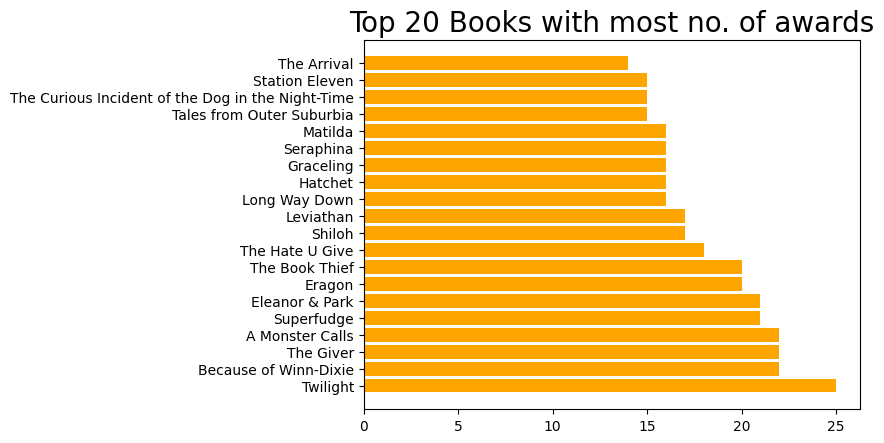

In [18]:
# Get titles and award counts for the top 20 books with most awards
no_of_awards = df['awards'].str.replace('[','').str.replace(']','').str.split(',').apply(lambda lst: len([x.strip() for x in lst if x.strip() != ''])).sort_values(ascending = False).head(20)
ax = plt.barh(width= no_of_awards.values, y = df.loc[no_of_awards.index,'title'], color = 'orange')
plt.plot(figsize = (10,10), ax =ax)
plt.title('Top 20 Books with most no. of awards', size = 20);



In [19]:
df.language.value_counts()

language
English                                  21355
Arabic                                     505
Spanish                                    339
French                                     290
German                                     261
                                         ...  
Tagalog                                      1
Panjabi; Punjabi                             1
Aromanian; Arumanian; Macedo-Romanian        1
Afrikaans                                    1
Aleut                                        1
Name: count, Length: 67, dtype: int64

# Feature Engineering

In [20]:
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
0,6060069-tracy,Tracy,NaN,Gary McKay,4.17,...,[],https://i.gr-assets.com/images/S/compressed.ph...,83,1,2.86
1,16705.Summerland,Summerland,NaN,Michael Chabon,3.56,...,[],https://i.gr-assets.com/images/S/compressed.ph...,100,1,NaN


In [21]:
# we will use only few columns
df = df[['title','author','description','genres', 'coverImg']]
df.head()

,title,author,description,genres,coverImg
0,Tracy,Gary McKay,"On Christmas Day 1974, Australia woke up to th...","['Nonfiction', 'Australia', 'History']",https://i.gr-assets.com/images/S/compressed.ph...
1,Summerland,Michael Chabon,Ethan Feld has never been prone to adventure o...,"['Fantasy', 'Fiction', 'Young Adult', 'Basebal...",https://i.gr-assets.com/images/S/compressed.ph...
2,Clockers,Richard Price,\n Novelist and Academy Award–nominated scree...,"['Fiction', 'Crime', 'Mystery', 'Thriller', 'M...",https://i.gr-assets.com/images/S/compressed.ph...
3,What Is Real?: The Unfinished Quest for the Me...,Adam Becker (Goodreads Author),The untold story of the heretical thinkers who...,"['Science', 'Nonfiction', 'Physics', 'Philosop...",https://i.gr-assets.com/images/S/compressed.ph...
4,The House We Grew Up In,Lisa Jewell (Goodreads Author),Meet the Bird FamilyAll four children have an ...,"['Fiction', 'Contemporary', 'Chick Lit', 'Audi...",https://i.gr-assets.com/images/S/compressed.ph...


In [22]:
#check null values in filtered df
df.isna().sum()

title            0
author           0
description    659
genres           0
coverImg       318
dtype: int64

In [23]:
#drop null
df.dropna(inplace = True)

In [24]:
#check null again
df.isna().sum()

title          0
author         0
description    0
genres         0
coverImg       0
dtype: int64

In [25]:
df.shape

(25357, 5)

In [26]:
# preprocess genres
df.genres = df.genres.str.lower().str.replace(' ','').apply(eval).str.join(' ') #removing spaces between words

In [27]:
# preprocess author
df['author'] = df['author'].str.replace(' ','').str.replace(',',' ') #removing spaces between name and surname 

df['author'] = df['author'].str.replace(r'\(.+\)','',regex = True).str.replace(r'\s+',' ',regex = True).str.strip() #removing parentheses

df['author'] = df['author'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip() #removing punctuations



In [28]:
# preprocessing description
stop = r'\b('+ '|'.join(stopwords.words('english'))+r')\b'  # stopwords with regex

df['description'] = df['description'].str.lower().str.replace(stop,' ',regex = True) # removing stopwords




In [29]:
#create new column : tags = author + description + genres
df['tags'] = df['author'] + ' ' + df['description'] + ' ' + df['genres']
df.head()

,title,author,description,genres,coverImg,tags
0,Tracy,garymckay,"christmas day 1974, australia woke new...",nonfiction australia history,https://i.gr-assets.com/images/S/compressed.ph...,"garymckay christmas day 1974, australia woke..."
1,Summerland,michaelchabon,ethan feld never prone adventure atten...,fantasy fiction youngadult baseball sports chi...,https://i.gr-assets.com/images/S/compressed.ph...,michaelchabon ethan feld never prone adv...
2,Clockers,richardprice,\n novelist academy award–nominated screenw...,fiction crime mystery thriller mysterythriller...,https://i.gr-assets.com/images/S/compressed.ph...,richardprice \n novelist academy award–nomi...
3,What Is Real?: The Unfinished Quest for the Me...,adambecker,untold story heretical thinkers dared ...,science nonfiction physics philosophy history ...,https://i.gr-assets.com/images/S/compressed.ph...,adambecker untold story heretical thinke...
4,The House We Grew Up In,lisajewell,meet bird familyall four children idylli...,fiction contemporary chicklit audiobook myster...,https://i.gr-assets.com/images/S/compressed.ph...,lisajewell meet bird familyall four children...


In [30]:
#preprocess tags
df['tags'] = df['tags'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(r'\s+',' ',regex = True).str.strip()  #removing punctuations

In [31]:
#stemming
ps = PorterStemmer()
df['tags'] =df['tags'].str.split(' ').apply(lambda x:[ps.stem(i) for i in x])

df.tags = df.tags.str.join(' ')  # list to text

In [32]:
#saving data
data.loc[df.index,['title','author','coverImg']].to_parquet('books_modified.parquet', index = False, compression = 'brotli')

In [33]:
#tag vectorization
tfidf = TfidfVectorizer(max_features=4000, stop_words = 'english')
vec = tfidf.fit_transform(df['tags']).toarray().astype(np.float16)

In [34]:
#vec size
vec.nbytes/1024/1024

193.45855712890625

In [35]:
x = tfidf.transform(["a young adult vampire-romance novel by Stephenie Meyer, launching a massive franchise including four main books and a five-film saga. It follows 17-year-old Bella Swan as she moves to Forks, Washington, falling for Edward Cullen, a 104-year-old vampire. The story focuses on their dangerous romance, Edward's vegetarian vampire family, and threats from hostile vampires."]).toarray().astype(np.float16)

In [36]:
#let's get most similar books
similar = list(enumerate(cosine_similarity(x,vec)[0]))

In [37]:
#top 10 indices of similar books
indices = [i for i, j in sorted(similar, key = lambda x :x[1], reverse=True)[:10]]

In [38]:
#metadata of similar books
pd.read_parquet('books_modified.parquet').iloc[indices]

,title,author,coverImg
15986,Midnight Sun,Stephenie Meyer,https://i.gr-assets.com/images/S/compressed.ph...
5791,"Twilight: The Graphic Novel, Vol. 2","Young Kim (Art/Adaptation), Stephenie Meyer (C...",https://i.gr-assets.com/images/S/compressed.ph...
5699,Last Friends,Jane Gardam,https://i.gr-assets.com/images/S/compressed.ph...
19083,"Twilight: The Graphic Novel, Vol. 1","Young Kim (Art/Adaptation), Stephenie Meyer (C...",https://i.gr-assets.com/images/S/compressed.ph...
20984,The Pursuit,Lori Wick,https://i.gr-assets.com/images/S/compressed.ph...
19606,The Ravenscar Dynasty,Barbara Taylor Bradford (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
13202,The Leaf,Jo-Ann M. Rodriguez,https://i.gr-assets.com/images/S/compressed.ph...
22186,Silent in the Grave,Deanna Raybourn (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
19482,600 Hours of Edward,Craig Lancaster (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
13550,The Nine Days Queen,Karleen Bradford (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...


In [39]:
joblib.dump(tfidf, 'tfidf.joblib')

['tfidf.joblib']

In [40]:
#saving book vector
np.savez_compressed("book_vec.npz", vec=vec)